# BERT Encoder

> The original architecture proposed in the Transformer paper contains both an Encoder and a Decoder — the Encoder reads and understands the input, while the Decoder generates the output token by token. In previous sections we only used the Decoder side and built a Decoder-Only model like GPT.
>
> This section starts from the complete original Transformer, then turns to the Encoder side and builds an Encoder-Only model, MiniBERT, from scratch. After removing the causal mask, each token's view changes from unidirectional to bidirectional, and the training objective shifts from "predict the next word" to "cover up some words and guess what they are from context" — MLM (Masked Language Modeling).

The intuition behind MLM is not complicated: cover up one word in a sentence and ask someone to guess what was hidden. For example, "I `__` you" — given only three words, a native speaker can probably guess what goes in the blank. That is exactly what BERT learns to do.

GPT's training revolves around generation: writing tokens one by one from left to right, never knowing what comes next. BERT does the opposite — instead of generating, it first reads the entire sentence, then answers questions about that sentence. Is the sentiment positive or negative? Which place names appear in the text? Do two sentences contradict each other? For these tasks, reading the whole thing first and then making a judgment is more direct than guessing word by word.


## 1. The Original Transformer: Encoder + Decoder

The 2017 Transformer paper ("Attention Is All You Need") proposed a complete Encoder-Decoder architecture for machine translation: the Encoder reads the source-language sentence, and the Decoder generates the target-language sentence token by token. [The Annotated Transformer](https://nlp.seas.harvard.edu/annotated-transformer/) is a classic line-by-line annotated implementation.

This architecture contains three kinds of attention:

- **Encoder self-attention**: bidirectional; every token can see all positions of the input sequence
- **Decoder self-attention**: unidirectional (causal mask); during generation it can only see what has already been produced
- **Cross-attention**: each Decoder position queries the Encoder's output to obtain source-language information

Below we implement this complete architecture from scratch and train it on a copy task — teaching the model to output the input sequence verbatim. The copy task is simple, but it fully demonstrates the Encoder-Decoder workflow: the Encoder encodes the input, and the Decoder decodes the output step by step.


In [1]:
# ============================================================
# Original Transformer: full Encoder + Decoder implementation
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import math

torch.manual_seed(42)


# Multi-head attention, supports mask (causal mask / padding mask)
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        self.d_k = d_model // num_heads
        self.num_heads = num_heads
        self.W_Q = nn.Linear(d_model, d_model, bias=False)
        self.W_K = nn.Linear(d_model, d_model, bias=False)
        self.W_V = nn.Linear(d_model, d_model, bias=False)
        self.W_O = nn.Linear(d_model, d_model, bias=False)

    def forward(self, query, key, value, mask=None):
        B = query.size(0)
        Q = self.W_Q(query).view(B, -1, self.num_heads, self.d_k).transpose(1, 2)
        K = self.W_K(key).view(B, -1, self.num_heads, self.d_k).transpose(1, 2)
        V = self.W_V(value).view(B, -1, self.num_heads, self.d_k).transpose(1, 2)
        scores = (Q @ K.transpose(-2, -1)) / math.sqrt(self.d_k)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, float('-inf'))
        attn = F.softmax(scores, dim=-1)
        out = (attn @ V).transpose(1, 2).contiguous().view(
            B, -1, self.num_heads * self.d_k
        )
        return self.W_O(out)


# Sinusoidal positional encoding (the original Transformer approach)
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=100):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float()
            * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]


# Encoder layer: bidirectional self-attention + FFN
class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff):
        super().__init__()
        self.attn = MultiHeadAttention(d_model, num_heads)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Linear(d_ff, d_model),
        )
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x, mask=None):
        normed = self.norm1(x)
        x = x + self.attn(normed, normed, normed, mask)
        x = x + self.ffn(self.norm2(x))
        return x


# Decoder layer: causal self-attention + cross-attention + FFN
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.cross_attn = MultiHeadAttention(d_model, num_heads)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Linear(d_ff, d_model),
        )
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)

    def forward(self, x, memory, src_mask=None, tgt_mask=None):
        # Causal self-attention: can only see already-generated tokens
        normed = self.norm1(x)
        x = x + self.self_attn(normed, normed, normed, tgt_mask)
        # Cross-attention: query the Encoder's output
        normed = self.norm2(x)
        x = x + self.cross_attn(normed, memory, memory, src_mask)
        # FFN
        x = x + self.ffn(self.norm3(x))
        return x


# Complete Encoder-Decoder Transformer
class EncoderDecoderTransformer(nn.Module):
    def __init__(self, src_vocab, tgt_vocab, d_model=64, num_heads=4,
                 d_ff=256, num_layers=2, max_len=50):
        super().__init__()
        self.d_model = d_model
        self.src_embed = nn.Sequential(
            nn.Embedding(src_vocab, d_model),
            PositionalEncoding(d_model, max_len),
        )
        self.tgt_embed = nn.Sequential(
            nn.Embedding(tgt_vocab, d_model),
            PositionalEncoding(d_model, max_len),
        )
        self.encoder_layers = nn.ModuleList([
            EncoderLayer(d_model, num_heads, d_ff) for _ in range(num_layers)
        ])
        self.decoder_layers = nn.ModuleList([
            DecoderLayer(d_model, num_heads, d_ff) for _ in range(num_layers)
        ])
        self.norm = nn.LayerNorm(d_model)
        self.generator = nn.Linear(d_model, tgt_vocab)

    def encode(self, src, src_mask=None):
        x = self.src_embed(src)
        for layer in self.encoder_layers:
            x = layer(x, src_mask)
        return self.norm(x)

    def decode(self, tgt, memory, src_mask=None, tgt_mask=None):
        x = self.tgt_embed(tgt)
        for layer in self.decoder_layers:
            x = layer(x, memory, src_mask, tgt_mask)
        return self.norm(x)

    def forward(self, src, tgt, src_mask=None, tgt_mask=None):
        memory = self.encode(src, src_mask)
        out = self.decode(tgt, memory, src_mask, tgt_mask)
        return self.generator(out)


# Create the model
VOCAB_SIZE = 11  # token 0-10, where 0 is the start symbol
transformer = EncoderDecoderTransformer(VOCAB_SIZE, VOCAB_SIZE)
total_params = sum(p.numel() for p in transformer.parameters())
print(f"Model parameter count: {total_params:,}")
print(f"Architecture: {len(transformer.encoder_layers)} Encoder layers"
      f" + {len(transformer.decoder_layers)} Decoder layers")
print("Attention types: Encoder self-attention (bidirectional)"
      " + Decoder self-attention (causal) + Cross-attention")


Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.

Read the values printed above and connect them to the concept in this cell.  Epoch   0 | Loss: 2.4860
  Epoch  50 | Loss: 0.9780
  Epoch 100 | Loss: 0.0262
  Epoch 150 | Loss: 0.0129
  Epoch 200 | Loss: 0.0056
  Epoch 250 | Loss: 0.0038
  Epoch 299 | Loss: 0.0028

Loss
Read the values printed above and connect them to the concept in this cell.Input: [10, 4, 3, 9, 8, 1, 9, 5]Output: [10, 4, 3, 9, 8, 1, 9, 5]Read the values printed above and connect them to the concept in this cell.

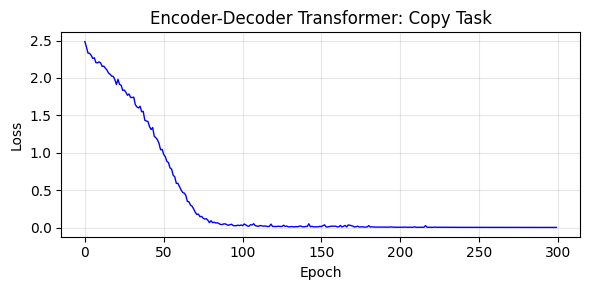

In [2]:
# ============================================================
# Copy task: train the Transformer to output the input sequence verbatim
# ============================================================

import torch
import torch.nn.functional as F

torch.manual_seed(42)

SEQ_LEN = 8
BATCH_SIZE = 32
NUM_EPOCHS = 300

optimizer = torch.optim.Adam(transformer.parameters(), lr=0.001)


def make_causal_mask(seq_len):
    # Causal mask: lower-triangular matrix, prevents the Decoder from seeing future tokens
    return torch.tril(torch.ones(seq_len, seq_len)).unsqueeze(0).unsqueeze(0)


def make_batch():
    # Generate training data: random sequence -> verbatim copy
    src = torch.randint(1, 11, (BATCH_SIZE, SEQ_LEN))  # token 1-10
    # Decoder input: start symbol 0 + first seq_len-1 of src
    tgt_input = torch.cat([
        torch.zeros(BATCH_SIZE, 1, dtype=torch.long),
        src[:, :-1]
    ], dim=1)
    tgt_output = src  # target is the original sequence
    return src, tgt_input, tgt_output


tgt_mask = make_causal_mask(SEQ_LEN)

# Training
print("=== Training Encoder-Decoder Transformer (copy task) ===")
transformer.train()
losses = []
for epoch in range(NUM_EPOCHS):
    src, tgt_in, tgt_out = make_batch()
    logits = transformer(src, tgt_in, tgt_mask=tgt_mask)
    loss = F.cross_entropy(
        logits.reshape(-1, VOCAB_SIZE), tgt_out.reshape(-1)
    )
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    if epoch % 50 == 0 or epoch == NUM_EPOCHS - 1:
        print(f"  Epoch {epoch:3d} | Loss: {loss.item():.4f}")

print(f"\nInitial Loss: {losses[0]:.4f} -> Final Loss: {losses[-1]:.4f}")

# ============================================================
# Test: autoregressive decoding (step-by-step generation, same as real translation inference)
# ============================================================
transformer.eval()
with torch.no_grad():
    test_src = torch.randint(1, 11, (1, SEQ_LEN))
    # Start from the start symbol, generate one token at a time
    generated = torch.zeros(1, 1, dtype=torch.long)
    for step in range(SEQ_LEN):
        mask = make_causal_mask(step + 1)
        logits = transformer(test_src, generated, tgt_mask=mask)
        next_tok = logits[:, -1, :].argmax(dim=-1, keepdim=True)
        generated = torch.cat([generated, next_tok], dim=1)

    result = generated[:, 1:]  # drop the start symbol
    print(f"\n=== Test (autoregressive decoding) ===")
    print(f"  Input:    {test_src.tolist()[0]}")
    print(f"  Output:   {result.tolist()[0]}")
    print(f"  Copy correct: {(result == test_src).all().item()}")

# Loss curve
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 3))
plt.plot(losses, 'b-', linewidth=1)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Encoder-Decoder Transformer: Copy Task')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 2. Encoder and Decoder

The complete Transformer above uses both an Encoder and a Decoder. In practice, using only one side also works very well: GPT uses only the Decoder, and BERT uses only the Encoder. The fundamental difference lies in the direction of attention — given the sentence "I ate the apple", under a causal mask the model sees "I ate" without knowing whether the next word is "apple" or "phone" — it can only guess. Under bidirectional attention, the model simultaneously sees "I", "ate", "the", "apple" — every word can reference all positions of the sentence, so it knows "apple" is the object rather than the subject.

This difference determines what each model is suited for. GPT is suited for generation — each step can only see what has already been written, and the next word becomes visible only after the current one is produced. BERT is suited for understanding — it reads the entire text first, then answers any question about it.

Using "I ate the apple" to look at each token's field of view:

```
BERT (bidirectional, no mask)        GPT (causal, with mask)

  "I"    -> I, ate, the, apple       "I"    -> I
  "ate"  -> I, ate, the, apple       "ate"  -> I, ate
  "the"  -> I, ate, the, apple       "the"  -> I, ate, the
  "apple"-> I, ate, the, apple       "apple"-> I, ate, the, apple
```

BERT imposes no restriction on attention — every position in the matrix is visible. GPT applies a lower-triangular matrix as a mask to block "future" information. This seemingly simple difference directly determines the applicable scenarios of the two architectures.


## 3. BERT's Input Representation

BERT's input is not simply a single Embedding. It is the **sum of three Embeddings**:

```
Input = Token Embedding + Segment Embedding + Position Embedding
         ^                    ^                    ^
   "which word is this"   "sentence A or B"    "at which position"
```

How does this differ from GPT? GPT only has Token + Position and does not need Segment (because GPT does not handle "the relationship between two sentences").

**Why does BERT need Segment Embedding?** Because the NSP (Next Sentence Prediction) task requires judging the relationship between two sentences.

The code below demonstrates BERT's complete input construction process:


In [3]:
# ============================================================
# Manually construct BERT's input from scratch, step by step
# ============================================================

# Simulate a small BERT configuration
import torch
import torch.nn as nn
torch.manual_seed(42)
VOCAB_SIZE = 100
D_MODEL = 16
MAX_LEN = 20
NUM_SEGMENTS = 2  # sentence A or sentence B

# Three Embeddings
token_embed = nn.Embedding(VOCAB_SIZE, D_MODEL)
segment_embed = nn.Embedding(NUM_SEGMENTS, D_MODEL)
position_embed = nn.Embedding(MAX_LEN, D_MODEL)

# Simulated input: two sentences
#   [CLS] I like cats [SEP] He likes dogs [SEP]
#   where [CLS]=1, [SEP]=2

sentence_A = [1, 5, 8, 3, 2]    # [CLS] I like cats [SEP]
sentence_B = [6, 8, 4, 2]        # He likes dogs [SEP]
full_ids = sentence_A + sentence_B
seq_len = len(full_ids)

print("Step 1: Token IDs")
print(f"  Input: {full_ids}")
print(f"  Meaning: [CLS] I like cats [SEP] He likes dogs [SEP]")

# Segment IDs: sentence A tokens get 0, sentence B tokens get 1
segment_ids = [0] * len(sentence_A) + [1] * len(sentence_B)
print(f"\nStep 2: Segment IDs")
print(f"  Segments: {segment_ids}")
print(f"  Meaning: first {len(sentence_A)} belong to sentence A (0), last {len(sentence_B)} belong to sentence B (1)")

# Position IDs: 0, 1, 2, ..., seq_len-1
position_ids = list(range(seq_len))
print(f"\nStep 3: Position IDs")
print(f"  Positions: {position_ids}")

# ============================================================
# Sum the three Embeddings
# ============================================================
tokens_t = torch.tensor(full_ids)
segments_t = torch.tensor(segment_ids)
positions_t = torch.tensor(position_ids)

tok_emb = token_embed(tokens_t)    # (seq_len, D_MODEL)
seg_emb = segment_embed(segments_t)  # (seq_len, D_MODEL)
pos_emb = position_embed(positions_t)  # (seq_len, D_MODEL)

input_embeddings = tok_emb + seg_emb + pos_emb

print(f"\nStep 4: Sum of three Embeddings")
print(f"  Token Embedding shape:    {tok_emb.shape}")
print(f"  Segment Embedding shape:  {seg_emb.shape}")
print(f"  Position Embedding shape: {pos_emb.shape}")
print(f"  After sum: {input_embeddings.shape}")

# Demonstration: the same word ("like", id=8) has different embeddings in the two sentences
# "like" is at position 2 in sentence A and position 1 in sentence B
idx_a = 2  # "like" in sentence A
idx_b = len(sentence_A) + 1  # "like" in sentence B

print(f"\n★ Key observation: the same word has different embeddings at different positions + different sentences")
print(f"  'like' in sentence A (pos={idx_a}, seg=0), final embedding (first 6 dims):")
print(f"    {input_embeddings[idx_a, :6].detach()}")
print(f"  'like' in sentence B (pos={idx_b}, seg=1), final embedding (first 6 dims):")
print(f"    {input_embeddings[idx_b, :6].detach()}")
print(f"  Are they the same? {(input_embeddings[idx_a] == input_embeddings[idx_b]).all().item()}")
print(f"  -> Even for the same word, different position and segment produce different embeddings!")


Step 1: Token IDs
  Input: [1, 5, 8, 3, 2, 6, 8, 4, 2]
Read the values printed above and connect them to the concept in this cell.
Step 2: Segment IDs
  Segments: [0, 0, 0, 0, 0, 1, 1, 1, 1]
Read the values printed above and connect them to the concept in this cell.
Step 3: Position IDs
  Positions: [0, 1, 2, 3, 4, 5, 6, 7, 8]

Read the values printed above and connect them to the concept in this cell.  Token Embedding shape:    torch.Size([9, 16])
  Segment Embedding shape:  torch.Size([9, 16])
  Position Embedding shape: torch.Size([9, 16])
Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.    tensor([ 1.7462,  1.3668, -1.6681, -0.8311, -0.6420,  3.6566])
Read the values printed above and connect them to the concept in this cell.    tensor([ 1.8207, -0.1974, -1.4914,  0.9783, -1.8119,  1.2722])
Read the values 

## 4. MLM Pre-training

GPT's training task is "given the preceding words, predict the next word" (autoregressive).
BERT's training task is "cover up some words in the middle, and ask the model to guess what they are" (MLM).

```
GPT training:   I -> love -> you -> China
                can only look -> (one direction)

BERT training:  I [MASK] you China   ->  guess [MASK] is "love"
                look left    look right
```

BERT can see both left and right simultaneously — because its attention is **bidirectional** (no causal mask).
This makes it good at "understanding" but unable to generate — because during training it never learned to "produce words one at a time".


In [4]:
# ============================================================
# Demonstrate BERT's bidirectional Attention (vs GPT's causal Attention)
# ============================================================
import torch
seq_len = 6

# GPT's causal mask: each position can only see itself and earlier positions
causal_mask = torch.tril(torch.ones(seq_len, seq_len))

# BERT has no mask: each position sees all positions (bidirectional)
bert_mask = torch.ones(seq_len, seq_len)

tokens = ["[CLS]", "I", "love", "you", "China", "[SEP]"]

print("=== GPT's causal Attention (unidirectional) ===")
print(f"Tokens: {tokens}")
print()
for i in range(seq_len):
    visible = [tokens[j] for j in range(seq_len) if causal_mask[i, j] == 1]
    print(f"  Position {i} ('{tokens[i]}') can see: {visible}")

print(f"\n=== BERT's Attention (bidirectional) ===")
for i in range(seq_len):
    visible = [tokens[j] for j in range(seq_len) if bert_mask[i, j] == 1]
    print(f"  Position {i} ('{tokens[i]}') can see: {visible}")

print(f"\nKey difference:")
print(f"  GPT:  'you' cannot see 'China' (not yet generated)")
print(f"  BERT: 'you' can see 'China' (whole sentence is known, bidirectional)")
print(f"  -> BERT has stronger context understanding! But cannot do generation.")


Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed

## 5. MLM Training Demo

The idea behind MLM training is straightforward, but it differs fundamentally from autoregressive language model training:

- **Autoregressive models** (e.g. GPT): input token[0:n], predict token[1:n+1], and every position contributes to the loss. This is a "predict from left to right, one at a time" pattern.
- **MLM**: only randomly mask 15% of tokens. The model sees the full context (including content to the right of the masked positions), but only needs to predict the masked 15%. Loss is computed only at the masked positions.

Why does MLM only compute loss on 15% of positions? Because unmasked tokens are directly visible to the model. If we asked the model to predict all tokens without masking, it would simply learn to copy the input — it would learn nothing.

Below we build a MiniBERT and demonstrate the complete MLM training pipeline:
1. Randomly mask 15% of tokens (80% replaced with [MASK], 10% replaced with a random token, 10% left unchanged)
2. The model uses bidirectional context to predict the masked tokens
3. Loss is computed only at the masked positions


In [5]:
# ============================================================
# MiniBERT: Encoder only (bidirectional Attention, no causal mask)
# ============================================================
import torch.nn.functional as F
import math
import torch.nn as nn
import torch
class MiniBERTEncoder(nn.Module):
    """Similar Transformer Block to MiniGPT, but without causal mask (bidirectional)"""
    def __init__(self, d_model, num_heads):
        super().__init__()
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads
        self.W_Q = nn.Linear(d_model, d_model, bias=False)
        self.W_K = nn.Linear(d_model, d_model, bias=False)
        self.W_V = nn.Linear(d_model, d_model, bias=False)
        self.W_O = nn.Linear(d_model, d_model, bias=False)

    def forward(self, x):
        B, S, D = x.shape
        Q = self.W_Q(x).view(B, S, self.num_heads, self.d_k).transpose(1, 2)
        K = self.W_K(x).view(B, S, self.num_heads, self.d_k).transpose(1, 2)
        V = self.W_V(x).view(B, S, self.num_heads, self.d_k).transpose(1, 2)
        scores = (Q @ K.transpose(-2, -1)) / math.sqrt(self.d_k)
        # No mask! Bidirectional!
        attn = F.softmax(scores, dim=-1)
        out = (attn @ V).transpose(1, 2).contiguous().view(B, S, D)
        return self.W_O(out)

class MiniBERTBlock(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        self.attention = MiniBERTEncoder(d_model, num_heads)
        self.norm1 = nn.LayerNorm(d_model)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, 4 * d_model),
            nn.GELU(),
            nn.Linear(4 * d_model, d_model),
        )
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x):
        x = x + self.attention(self.norm1(x))
        x = x + self.ffn(self.norm2(x))
        return x

class MiniBERT(nn.Module):
    def __init__(self, vocab_size, d_model=64, num_heads=4, num_layers=2, max_len=64):
        super().__init__()
        self.d_model = d_model
        self.token_embedding = nn.Embedding(vocab_size, d_model)
        # BERT uses learned position embeddings (not sinusoidal)
        self.position_embedding = nn.Embedding(max_len, d_model)
        self.blocks = nn.ModuleList([
            MiniBERTBlock(d_model, num_heads) for _ in range(num_layers)
        ])
        self.norm_final = nn.LayerNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size)
        self.max_len = max_len

    def encode(self, x):
        """Return hidden states for each position, reusable for classification/QA tasks"""
        B, S = x.shape
        positions = torch.arange(S, device=x.device).unsqueeze(0)
        x_emb = self.token_embedding(x) + self.position_embedding(positions)
        for block in self.blocks:
            x_emb = block(x_emb)
        x_emb = self.norm_final(x_emb)
        return x_emb

    def forward(self, x):
        x_emb = self.encode(x)
        return self.lm_head(x_emb)

print("MiniBERT defined (bidirectional Attention, no causal mask)")


Read the values printed above and connect them to the concept in this cell.

In [6]:
import torch.nn.functional as F
# ============================================================
# MLM training data construction + training demo
# ============================================================
import torch
VOCAB_SIZE = 50
MASK_ID = 3  # [MASK] token ID

torch.manual_seed(42)
model = MiniBERT(VOCAB_SIZE, d_model=64, num_heads=4, num_layers=2)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Simulated training sentences
sentences = [
    [5, 8, 10, 6, 9, 4],   # I like cats they very cute
    [5, 12, 13, 14, 4],    # I hate rainy days
    [7, 8, 11, 6, 15, 4],  # He likes dogs they loyal
    [5, 16, 17, 18, 4],    # I am learning programming
    [7, 16, 19, 20, 4],    # He is listening to music
    [5, 21, 22, 9, 23, 4], # I think math very hard
]

# MLM data construction function
def create_mlm_batch(sentences, mask_prob=0.15):
    """
    Same as real BERT:
    - 15% of tokens are selected
    - Of those, 80% replaced with [MASK]
    - 10% replaced with a random token
    - 10% left unchanged (but still predicted)
    """
    # Padding
    max_len = max(len(s) for s in sentences)
    batch_size = len(sentences)
    input_ids = torch.zeros(batch_size, max_len, dtype=torch.long)
    labels = torch.full((batch_size, max_len), -100, dtype=torch.long)  # -100 = ignore

    for i, sent in enumerate(sentences):
        input_ids[i, :len(sent)] = torch.tensor(sent)

        # Select positions to mask (15%), but don't mask first and last
        maskable = list(range(1, len(sent) - 1))
        num_mask = max(1, int(len(maskable) * mask_prob))
        mask_positions = torch.randperm(len(maskable))[:num_mask]

        for pos_idx in mask_positions:
            pos = maskable[pos_idx]
            labels[i, pos] = sent[pos]  # record original token
            rand = torch.rand(1).item()
            if rand < 0.8:
                input_ids[i, pos] = MASK_ID  # 80%: replace with [MASK]
            elif rand < 0.9:
                input_ids[i, pos] = torch.randint(5, 25, (1,)).item()  # 10%: random
            # 10%: keep unchanged

    return input_ids, labels

# Create batch
input_ids, labels = create_mlm_batch(sentences)

print("=== MLM Training Data Examples ===")
print(f"MASK_ID = {MASK_ID}")
print()
for i in range(len(sentences)):
    print(f"Sentence {i+1}:")
    print(f"  Original: {sentences[i]}")
    print(f"  Input:    {input_ids[i].tolist()}")
    label_row = labels[i].tolist()
    print(f"  Labels:   {[('MASK->'+str(l) if l != -100 else 'ignore') for l in label_row]}")
    print()

# ============================================================
# Training
# ============================================================
print("=== Training MiniBERT (MLM) ===")
NUM_EPOCHS = 200
losses = []

model.train()
for epoch in range(NUM_EPOCHS):
    optimizer.zero_grad()
    logits = model(input_ids)  # (B, S, V)
    loss = F.cross_entropy(
        logits.view(-1, VOCAB_SIZE),
        labels.view(-1),
        ignore_index=-100  # ignore non-masked positions
    )
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

    if epoch % 20 == 0 or epoch == NUM_EPOCHS - 1:
        print(f"Epoch {epoch:3d} | Loss: {loss.item():.4f}")

print(f"\nInitial Loss: {losses[0]:.4f} -> Final Loss: {losses[-1]:.4f}")


Read the values printed above and connect them to the concept in this cell.MASK_ID = 3

Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Input: [5, 8, 3, 6, 9, 4]  labels: ['ignore', 'ignore', 'MASK→10', 'ignore', 'ignore', 'ignore']

Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Input: [5, 3, 13, 14, 4, 0]  labels: ['ignore', 'MASK→12', 'ignore', 'ignore', 'ignore', 'ignore']

Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Input: [7, 8, 11, 3, 15, 4]  labels: ['ignore', 'ignore', 'ignore', 'MASK→6', 'ignore', 'ignore']

Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Input: [5, 16, 

Read the values printed above and connect them to the concept in this cell.Input: [5, 3, 10, 6, 3, 4]Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.

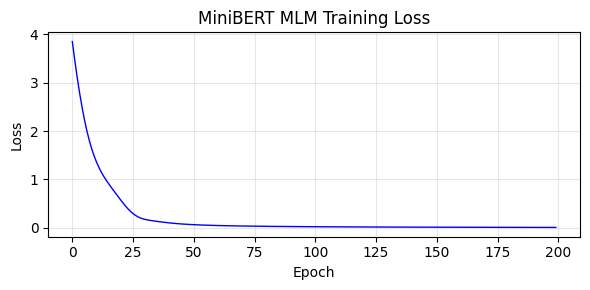

In [7]:
# ============================================================
# Test: MLM prediction results
# ============================================================
import torch
test_sentence = torch.tensor([[5, MASK_ID, 10, 6, MASK_ID, 4]])  # I [MASK] cats they [MASK] cute

model.eval()
with torch.no_grad():
    logits = model(test_sentence)
    predictions = logits.argmax(dim=-1)

print("=== MLM Prediction Results ===")
print(f"Input:      {test_sentence.tolist()[0]}")
print(f"            ['I', '[MASK]', 'cats', 'they', '[MASK]', 'cute']")
print(f"Predicted:  {predictions.tolist()[0]}")
print(f"            ['I', '?', 'cats', 'they', '?', 'cute']")
print(f"\nPosition 1 (predicted) = {predictions[0, 1].item()} (expected 8='like')")
print(f"Position 4 (predicted) = {predictions[0, 4].item()} (expected 9='very')")

# Visualize loss
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 3))
plt.plot(losses, 'b-', linewidth=1)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('MiniBERT MLM Training Loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 6. BERT's Fine-tuning Paradigm

After BERT is pre-trained, different downstream tasks only need a different classification head attached on top. The key question is: **where is the classification head attached?**

The pre-trained BERT body is a "general-purpose text encoder" — given a piece of text as input, it outputs a hidden state for each token. Different tasks require information from different positions:

| Task | What information is needed | Where to attach the classification head |
|------|---------------------------|----------------------------------------|
| **Single-sentence classification** (sentiment analysis) | Semantics of the whole sentence | `[CLS]` hidden -> classification layer |
| **Sentence-pair classification** (NLI, similarity) | Relationship between two sentences | `[CLS]` hidden -> classification layer |
| **Sequence labeling** (NER) | Category of each word | **Each token's** hidden -> individual classification layers |
| **Question answering** (SQuAD) | Start and end positions of the answer | Each token's hidden -> start/end classification layers |

Why do both single-sentence and sentence-pair classification use `[CLS]`? Because `[CLS]` sits at the very beginning of BERT's input. After passing through multiple layers of bidirectional attention, information from the entire sentence is aggregated into `[CLS]`'s hidden state — it serves as a "whole-sentence summary". Passing it through a classification layer is sufficient for sentence-level judgments.

Sequence labeling tasks (e.g. NER: labeling "Apple released a new phone" as `[ORG, O, O, O]`) require a category for each token individually, so we cannot just use `[CLS]` — we need to classify each position's hidden state separately.

Core insight: classic BERT fine-tuning typically adds a task head on top and fine-tunes the BERT body together with the task head; freezing BERT and training only the head is a resource-saving option, not the default paradigm. This differs from GPT's prompt engineering: BERT more often adapts to tasks through task heads and fine-tuning, while GPT more often adapts through prompting / SFT / RL.


In [8]:
import torch.nn as nn
# ============================================================
# Demo: Using MiniBERT for sentence classification
# ============================================================
import torch
class MiniBERTForClassification(nn.Module):
    """Attach a classification head on top of MiniBERT"""
    def __init__(self, bert, num_classes):
        super().__init__()
        self.bert = bert
        self.classifier = nn.Linear(bert.d_model, num_classes)

    def forward(self, x):
        hidden = self.bert.encode(x)  # (B, S, D)
        cls_output = hidden[:, 0, :]  # take [CLS] output
        return self.classifier(cls_output)  # -> (B, num_classes)

# Demo
VOCAB_SIZE = 50
bert_base = MiniBERT(VOCAB_SIZE, d_model=64, num_heads=4, num_layers=2)
clf_model = MiniBERTForClassification(bert_base, num_classes=2)  # binary: positive/negative

test_input = torch.randint(0, VOCAB_SIZE, (1, 10))
output = clf_model(test_input)
print(f"Input shape: {test_input.shape}")
print(f"Output shape: {output.shape}  <- (batch=1, classes=2)")
print(f"Output logits: {output.tolist()}")
print(f"\nThis is the complete pipeline for BERT sentiment analysis:")
print(f"  Input sentence -> BERT encoding -> take [CLS] -> classification layer -> positive/negative")


Input shape: torch.Size([1, 10])Output shape: torch.Size([1, 2]) ← (batch=1, classes=2)Output logits: [[-0.9360657930374146, 0.7153985500335693]]
Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.

## 7. Loading Real BERT Demo

Above we implemented MiniBERT from scratch, understanding the underlying mechanisms of the Encoder-only architecture and MLM training. Now let's load a real BERT model using HuggingFace transformers and see how the industrial-scale implementation maps to our own version.

The key things to notice: real BERT scales up in three dimensions —
- **Scale**: BERT-base has 12 Transformer blocks, 768-dimensional hidden size, 12 attention heads, totaling about 110M parameters
- **Vocabulary**: Uses a 30,522-token WordPiece vocabulary, far larger than the dozens of tokens in our demo
- **Pre-training data**: BooksCorpus (800M words) + English Wikipedia (2,500M words)

But the core architecture is identical to our MiniBERT: both are Encoder-only, both use bidirectional attention, and both learn contextual understanding through MLM pre-training.


In [9]:
# ============================================================
# Load real BERT using transformers
# ============================================================
import torch
try:
    from transformers import AutoTokenizer, AutoModel

    print("Loading bert-base-chinese...")
    tokenizer = AutoTokenizer.from_pretrained("bert-base-chinese")
    model = AutoModel.from_pretrained("bert-base-chinese")

    print(f"BERT parameter count: {sum(p.numel() for p in model.parameters()) / 1e6:.0f}M")
    print(f"Vocabulary size: {len(tokenizer)}")
    print()

    # Test: look at BERT's attention weights
    sentences = [
        "I love China",
        "The weather is nice today",
    ]

    inputs = tokenizer(sentences, padding=True, return_tensors="pt")
    print(f"Input IDs shape: {inputs['input_ids'].shape}")
    print(f"Attention mask: {inputs['attention_mask']}")
    print()

    # Forward pass
    with torch.no_grad():
        outputs = model(**inputs, output_attentions=True)

    print(f"Output last_hidden_state shape: {outputs.last_hidden_state.shape}")
    print(f"  -> (batch, seq_len, hidden_dim=768)")
    print()

    # Look at the last layer's attention (first head)
    last_layer_attn = outputs.attentions[-1]  # (batch, num_heads, seq_len, seq_len)
    print(f"Last layer attention shape: {last_layer_attn.shape}")
    print(f"  -> (batch, 12 heads, seq_len, seq_len)")
    print()

    # Show what each token in the first sentence attends to
    tokens1 = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])
    print(f"Sentence 1 tokens: {tokens1}")
    print(f"\nAttention distribution for each token (head 0):")
    for i, tok in enumerate(tokens1):
        attn_weights = last_layer_attn[0, 0, i]  # sample 0, head 0, position i
        top2 = attn_weights.topk(2)
        print(f"  '{tok}' most attends to: ", end="")
        for j, (idx, w) in enumerate(zip(top2.indices, top2.values)):
            print(f"'{tokens1[idx]}'({w:.2f})", end="  ")
        print()

except ImportError:
    print("transformers library not installed. Run: pip install transformers")
except Exception as e:
    print(f"Error loading BERT: {e}")
    print("(This is normal - if the network is unavailable or the model is too large, refer to the MiniBERT demo above)")


Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Vocabulary size: 21128
Input IDs shape: torch.Size([2, 8])Attention mask: tensor([[1, 1, 1, 1, 1, 1, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1]])

Output last_hidden_state shape: torch.Size([2, 8, 768])  → (batch, seq_len, hidden_dim=768)

Read the values printed above and connect them to the concept in this cell.  → (batch, 12 heads, seq_len, seq_len)

Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them

BertSdpaSelfAttention is used but `torch.nn.functional.scaled_dot_product_attention` does not support non-absolute `position_embedding_type` or `output_attentions=True` or `head_mask`. Falling back to the manual attention implementation, but specifying the manual implementation will be required from Transformers version v5.0.0 onwards. This warning can be removed using the argument `attn_implementation="eager"` when loading the model.


## 8. BERT vs. GPT Comparison

| | BERT (Encoder-Only) | GPT (Decoder-Only) |
|------|------|------|
| **Core task** | Understanding — "What does this sentence mean?" | Generation — "What should come next?" |
| **Pre-training** | MLM (mask and fill, 15% mask) | Autoregressive (predict next token) |
| **Attention** | Bidirectional (sees whole sentence) | Unidirectional / causal (sees only preceding) |
| **Input representation** | Token + Segment + Position | Token + Position (no Segment) |
| **Output** | Hidden state per position | Logits per position (but generation uses only the last) |
| **How to use** | Attach classification head and fine-tune | Change prompt / dialogue format |
| **Representative models** | BERT, RoBERTa, DeBERTa | GPT-3/4, LLaMA, Qwen, DeepSeek |
| **Applicable scenarios** | Understanding tasks (classification, NER, QA) | General generation + understanding (chat, code, reasoning) |

The last row of the table places BERT and GPT into "understanding" and "generation" respectively. In 2018, this distinction was accurate. But today, the GPT family of models has become good at both understanding and generation. This raises a question: why did Decoder-Only ultimately win, rather than Encoder-Only or Encoder-Decoder?

The answer is not a single reason, but the stacking of advantages across three dimensions.

**Higher training-token utilization.** This is the most critical technical difference. Suppose the training data is a 1024-token text. Decoder-Only trains with a Causal LM objective, where every position produces a training signal: position 0 predicts the token at position 1, position 1 predicts position 2, all the way up to position 1022 predicting position 1023. 1024 tokens yield 1023 training samples. Encoder-Decoder trains with a Prefix LM objective: the first 512 tokens go into the encoder, and the latter 512 tokens are predicted by the decoder. Only the latter 512 tokens produce a training signal — the earlier positions are processed but do not directly contribute to the loss. The effective training signal is halved.

At the trillion-token training scale, this difference is amplified: under the same compute budget, Decoder-Only extracts more training signal from every token, and perplexity drops faster. Google DeepMind ran a controlled experiment in 2024 (from 150M to 8B parameters, trained on 1.6T tokens) that directly verified this conclusion — under the same compute, Decoder-Only almost entirely dominated the compute-optimal frontier.

**Simpler architecture.** Decoder-Only has only one kind of attention: self-attention plus a causal mask. Encoder-Decoder has three: bidirectional self-attention in the encoder, causal self-attention in the decoder, and cross-attention connecting the two. Three kinds of attention mean more hyperparameters, more complex distributed-training communication, and engineering implementations that are more error-prone. When model parameter counts reach the hundreds of billions, every step of architectural simplification reduces the difficulty of training and debugging by an order of magnitude.

**More intuitive KV-cache at inference.** During generation, Decoder-Only only adds one new token at a time, and the K and V of historical tokens are cached in the KV-cache; the new token only needs to do one attention pass against the cache. Encoder-Decoder inference has to manage both the encoder output and the decoder's KV-cache, making memory management more complex. Although the encoder can process the entire prompt in parallel in one pass (this is its advantage), modern inference frameworks (continuous batching, prefix caching, etc.) have narrowed this advantage.

**But Encoder-Decoder has not been eliminated.** The same Google DeepMind experiment also found a fact worth noting: after instruction tuning, Encoder-Decoder's downstream-task performance caught up with Decoder-Only, and was even better on some tasks, with significantly higher inference throughput. Its lag in the pretrain stage is likely not due to lack of capability, but because the match between the prefix LM objective and downstream evaluation was worse than that of causal LM. However, the industry has already invested too much infrastructure and ecosystem in Decoder-Only, and the switching cost is too high.

BERT and GPT are two uses of the same Transformer paper — one uses the Encoder for understanding, the other uses the Decoder for generation. GPT won the scaling race, but the Encoder-Only route has not stopped evolving:

- RoBERTa removed BERT's NSP task (finding it unhelpful), using only MLM with more data and longer training, achieving significantly better results
- DistilBERT compressed BERT by 40% through knowledge distillation, speeding it up by 60%, while retaining 97% of performance
- DeBERTa improved the Attention mechanism (decoupling relative position from content), at one point surpassing human baselines on SuperGLUE
- ModernBERT (2024, released jointly by Answer.AI et al.) brought rotary position embeddings and longer context windows to the Encoder-Only architecture, comprehensively surpassing classic BERT on classification and retrieval tasks, demonstrating that this route still has irreplaceable value for understanding tasks
- Google has also continued investing in Encoder architectures: T5Gemma (2024) converts Gemma weights into an Encoder-Decoder architecture for sequence-to-sequence tasks, EmbeddingGemma (2025) uses an Encoder-Only architecture for text embeddings, and Gecko (2024) distills an efficient encoder from a large model for semantic search
- MLM's "cover some parts and ask the model to guess" strategy has been widely adopted by T5, BART, and even modern multimodal models

BERT uses bidirectional Attention for MLM, excelling at understanding but not at generation. GPT uses unidirectional Attention for autoregressive prediction, excelling at generation and developing emergent understanding abilities as scale grows. Decoder-Only ultimately won not because it was stronger on every dimension, but because the combination of Causal LM's training efficiency, architectural simplicity, and ecosystem inertia produced an overwhelming advantage in the specific scenario of large-scale training. But Encoder-Only remains the first choice for understanding tasks such as classification, retrieval, and sequence labeling.


## Summary

What we learned in this section:

- [ ] The original Transformer architecture contains both Encoder and Decoder: the Encoder encodes the input with bidirectional self-attention, and the Decoder generates the output step by step with causal self-attention + cross-attention
- [ ] GPT uses only the Decoder side, BERT uses only the Encoder side
- [ ] Encoder-only models (like BERT) use bidirectional Attention, allowing them to see the complete input sequence
- [ ] BERT's pre-training task is MLM (mask and fill), not autoregressive "predict the next token"
- [ ] BERT's input is the sum of three Embeddings: Token + Segment + Position
- [ ] During fine-tuning, a classification head is attached on top of BERT; the [CLS] token's representation is used for downstream tasks
- [ ] Three reasons Decoder-Only won: Causal LM has higher training-token utilization, simpler architecture, and more intuitive KV-cache engineering
- [ ] The Encoder-Only route keeps evolving: ModernBERT comprehensively surpasses classic BERT; Google's T5Gemma, EmbeddingGemma, Gecko and other models continue to push the Encoder architecture forward


## Exercises

> You can ask AI for help explaining the approach, but it is not recommended to ask AI to "complete this exercise outright."

**Exercise 1: MLM mask ratio**

BERT's MLM task defaults to masking 15% of tokens. This ratio was not chosen at random.

**Hint**: Think about what happens when too many or too few tokens are masked.


In [10]:
# Exercise 1: MLM mask ratio
# BERT's MLM defaults to masking 15% of tokens.
# Question: if the mask ratios are 5%, 15%, 50%, 80% respectively, what problems does each have?
# Replace the answer below with your choice (fill in a letter)
answer = "fill in your answer here"
# Options:
# A) 5% is too few, the model cannot learn enough fill-in ability; 80% is too many, context information is severely missing
# B) Both 5% and 80% are fine; 15% is just a convention
# C) The larger the mask ratio the better, because the model needs more prediction practice
# D) The smaller the mask ratio the better, to retain more context information
assert not answer.startswith("fill in"), "Please fill in your answer first"
assert answer in "ABCD", "Please fill in one of A/B/C/D"
correct = "A"
if answer == correct:
    print("✅ Exercise 1 passed: you understood the tradeoff of mask ratio — too few means nothing learned, too many means missing context.")
else:
    print(f"Your answer is {answer}, think again about what happens with too many or too few masks.")


**Exercise 2: BERT's Input Representation**

BERT's input is the sum of three Embeddings: Token Embedding + Segment Embedding + Position Embedding. Given a sentence pair `[CLS] cat sits on the mat [SEP] it is happy [SEP]`, answer the following questions:

1. In the Segment Embedding, do `cat` and `it` have the same segment id?
2. What is the position number of `[CLS]`'s Position Embedding? (Counting from 0)

Hint: Segment Embedding uses 0 for the first sentence and 1 for the second sentence. Position Embedding is numbered starting from 0.


In [11]:
# Exercise 2: BERT's Input Representation
# Question 1: Do cat and it have the same segment id?
q1_answer = "fill in yes or no"
# Question 2: What is the position id of [CLS]?
q2_answer = -1  # fill in a number here
assert q1_answer in ("yes", "no"), "Please fill in 'yes' or 'no'"
assert isinstance(q2_answer, int) and q2_answer >= 0, "Please fill in a non-negative integer"
# Verification
# Sentence 1: [CLS] cat sits on the mat [SEP] -> segment 0, position 0-7
# Sentence 2: it is happy [SEP] -> segment 1, position 8-12
if q1_answer == "no":
    print("✅ cat (segment 0) and it (segment 1) belong to different sentences, so their segment ids are different.")
else:
    print("Think again: cat is in the first sentence, it is in the second sentence.")
if q2_answer == 0:
    print("✅ [CLS] is the first token of the sequence, position id = 0.")
else:
    print(f"The position id of [CLS] should be 0; you filled in {q2_answer}.")


**Exercise 3: Attention Difference between Encoder and Decoder**

BERT (Encoder-Only) uses bidirectional Attention: every token can see every other token in the sequence. GPT (Decoder-Only) uses causal Attention (causal mask): every token can only see itself and earlier tokens. Given the input sequence `I love natural language` (6 tokens), write out:

1. In BERT, which positions can the token `language` (position 4) attend to?
2. In GPT, which positions can the token `language` (position 4) attend to?

Hint: BERT's Attention has no mask, GPT's Attention has a lower-triangular mask.


In [12]:
# Exercise 3: Attention Difference between Encoder and Decoder
# In BERT, which positions can the token at position 4 attend to?
# Fill in a list, e.g. [0, 1, 2, 3, 4, 5]
bert_positions = "fill in a list here"
# In GPT, which positions can the token at position 4 attend to?
gpt_positions = "fill in a list here"
assert isinstance(bert_positions, list), "bert_positions please fill in a list"
assert isinstance(gpt_positions, list), "gpt_positions please fill in a list"
bert_correct = [0, 1, 2, 3, 4, 5]  # bidirectional: can see all positions
gpt_correct = [0, 1, 2, 3, 4]       # causal: can only see itself and earlier
if set(bert_positions) == set(bert_correct):
    print("✅ BERT's bidirectional Attention: position 4 can see all 6 positions.")
else:
    print(f"BERT should be able to see all positions {bert_correct}; you filled in {bert_positions}")
if gpt_positions == gpt_correct:
    print("✅ GPT's causal Attention: position 4 can only see positions 0-4 (itself and earlier).")
else:
    print(f"GPT should only see {gpt_correct}; you filled in {gpt_positions}")
